# CS111 Project Template — 2D Heat Equation with the FFT

We solve the periodic 2D heat equation

$$u_t = \kappa (u_{xx} + u_{yy}), \qquad (x,y) \in [0,2\pi]^2$$

with periodic boundary conditions.

This notebook is a guided project template. The main idea is to solve the PDE in **Fourier space**, where the Laplacian becomes diagonal.


## From finite differences to Fourier methods

In finite differences, we approximate derivatives locally on a grid.

In Fourier methods, we represent the solution as a sum of global modes:

$$u(x,y,t) = \sum_{k,\ell} \hat u_{k,\ell}(t)e^{i(kx+\ell y)}.$$

These modes are eigenfunctions of the Laplacian:

$$\Delta e^{i(kx+\ell y)} = -(k^2+\ell^2)e^{i(kx+\ell y)}.$$

So the PDE becomes many independent scalar ODEs in Fourier space.


## Big picture of the algorithm

We will:

1. define a 2D periodic initial condition
2. compute its 2D FFT
3. build the 2D wave number arrays
4. evolve each Fourier mode exactly in time
5. inverse FFT back to physical space
6. visualize diffusion and spectral decay
7. animate the solution over time

The key scientific computing idea is:

> choose a basis that diagonalizes the operator.


## Step 0 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


## Step 1 — Heat equation in Fourier space

Start with

$$u_t = \kappa (u_{xx}+u_{yy}).$$

Write

$$u(x,y,t)=\sum_{k,\ell} \hat u_{k,\ell}(t)e^{i(kx+\ell y)}.$$

Since

$$\Delta e^{i(kx+\ell y)} = -(k^2+\ell^2)e^{i(kx+\ell y)},$$

each Fourier coefficient satisfies

$$\frac{d\hat u_{k,\ell}}{dt} = -\kappa (k^2+\ell^2) \hat u_{k,\ell}.$$

So the exact mode-by-mode solution is

$$\hat u_{k,\ell}(t) = e^{-\kappa (k^2+\ell^2)t} \hat u_{k,\ell}(0).$$

This is the formula we implement.


## Step 2 — Set up the 2D periodic grid

We work on $[0,2\pi)\times[0,2\pi)$ using a periodic grid.


In [2]:
Lx = 2.0 * np.pi
Ly = 2.0 * np.pi
nx = 128
ny = 128

x = np.linspace(0.0, Lx, nx, endpoint=False)
y = np.linspace(0.0, Ly, ny, endpoint=False)
dx = x[1] - x[0]
dy = y[1] - y[0]

X, Y = np.meshgrid(x, y, indexing='xy')
kappa = 0.08

print('Grid:', nx, 'x', ny)
print('dx =', dx)
print('dy =', dy)


Grid: 128 x 128
dx = 0.04908738521234052
dy = 0.04908738521234052


## Step 3 — Define a more intuitive initial condition

A simple and intuitive choice is a **hot disk** in the center of the domain.

This is a nice test because:

- it is easy to interpret in physical space
- it is not a single Fourier mode
- its Fourier spectrum contains many frequencies
- diffusion should round and smooth the sharp edge over time

Because the domain is periodic, the disk lives inside a periodic square.


In [3]:
def initial_condition_circle(X, Y, cx=np.pi, cy=np.pi, radius=0.9):
    """Return a circular hot spot centered at (cx, cy)."""
    R = np.sqrt((X - cx)**2 + (Y - cy)**2)
    u0 = np.zeros_like(X)
    u0[R <= radius] = 1.0
    return u0


u0 = initial_condition_circle(X, Y)


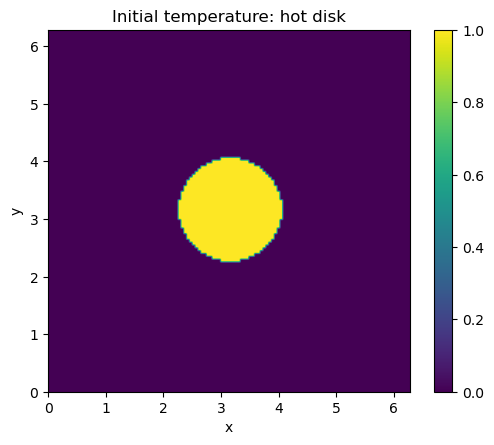

In [4]:
plt.figure(figsize=(5.5, 4.5))
plt.imshow(u0, origin='lower', extent=[0, Lx, 0, Ly])
plt.title('Initial temperature: hot disk')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar()
plt.tight_layout()
plt.show()


## Step 4 — Compute the 2D FFT

The 2D FFT gives the Fourier coefficients $\hat u_{k,\ell}(0)$ of the sampled initial condition.

We use `numpy.fft.fft2` and `numpy.fft.ifft2` as computational tools.


In [5]:
u0_hat = np.fft.fft2(u0)
print('Shape of Fourier coefficient array:', u0_hat.shape)


Shape of Fourier coefficient array: (128, 128)


## Step 5 — Build the wave number arrays

For the Fourier-space formula

$$\hat u_{k,\ell}(t) = e^{-\kappa (k^2+\ell^2)t}\hat u_{k,\ell}(0),$$

we need the wave numbers in both directions.


In [6]:
kx = 2.0 * np.pi * np.fft.fftfreq(nx, d=dx)
ky = 2.0 * np.pi * np.fft.fftfreq(ny, d=dy)
KX, KY = np.meshgrid(kx, ky, indexing='xy')
K2 = KX**2 + KY**2

print('K2 shape:', K2.shape)


K2 shape: (128, 128)


## Step 6 — Evolve the solution in Fourier space

Given time `t`, we evolve every Fourier mode exactly:

$$\hat u_{k,\ell}(t) = e^{-\kappa (k^2+\ell^2)t}\hat u_{k,\ell}(0).$$

Then we inverse FFT back to physical space.


In [7]:
def heat_solution_fft_2d(u0, K2, kappa, t):
    """Return the 2D heat equation solution at time t using the FFT."""
    u0_hat = np.fft.fft2(u0)
    decay = np.exp(-kappa * K2 * t)
    u_hat_t = decay * u0_hat
    u_t = np.fft.ifft2(u_hat_t)
    return np.real(u_t)


## Step 7 — Visualize the initial condition in Fourier space

Yes, it is completely feasible to look at the circle in Fourier space.

For a real-space disk with a sharp edge:

- the Fourier coefficients are spread over many modes
- the sharp edge creates strong high-frequency content
- diffusion will damp those higher frequencies first

We usually look at the **magnitude** of the Fourier coefficients rather than the raw complex values.

Because FFT output is ordered with zero frequency in the corner, we use `fftshift` to move low frequencies to the center of the image.


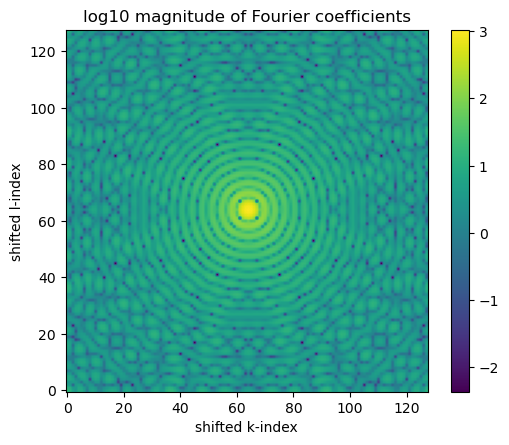

In [8]:
u0_hat_shifted = np.fft.fftshift(u0_hat)
spectrum0 = np.log10(np.abs(u0_hat_shifted) + 1e-12)

plt.figure(figsize=(5.5, 4.5))
plt.imshow(spectrum0, origin='lower')
plt.title('log10 magnitude of Fourier coefficients')
plt.xlabel('shifted k-index')
plt.ylabel('shifted l-index')
plt.colorbar()
plt.tight_layout()
plt.show()


## Step 8 — Plot the solution at several times

This should show the hot disk smoothing out over time.


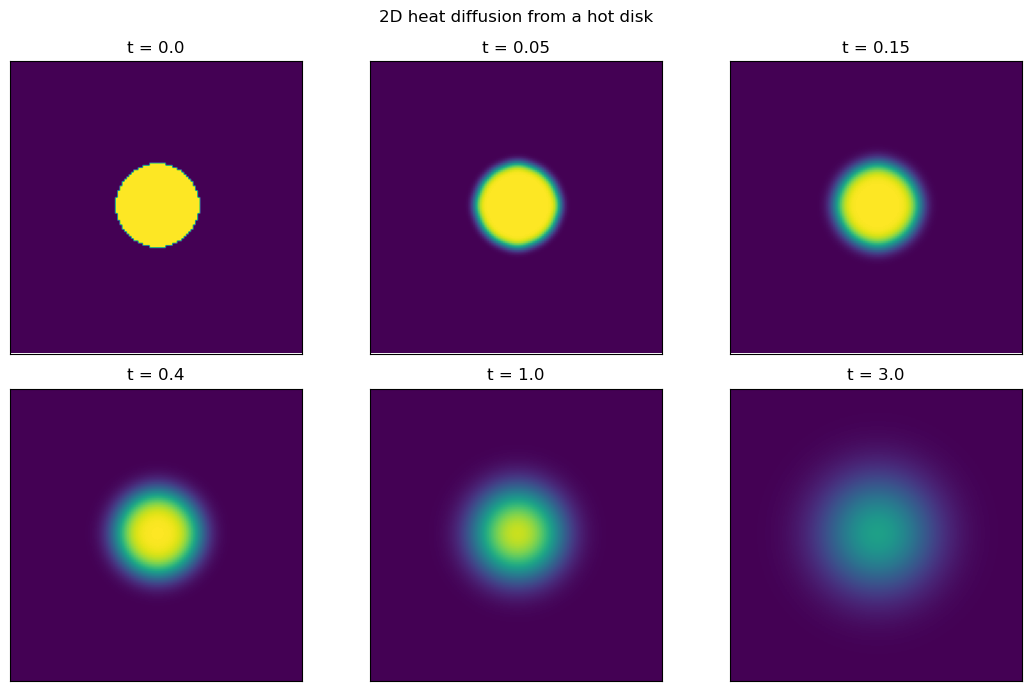

In [9]:
times = [0.0, 0.05, 0.15, 0.4, 1.0, 3.0]

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
axes = axes.ravel()

for ax, t in zip(axes, times):
    ut = heat_solution_fft_2d(u0, K2, kappa, t)
    ax.imshow(ut, origin='lower', extent=[0, Lx, 0, Ly], vmin=0.0, vmax=1.0)
    ax.set_title(f't = {t}')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('2D heat diffusion from a hot disk')
plt.tight_layout()
plt.show()


## Step 9 — Compare physical space and Fourier space at a later time

This makes the smoothing mechanism clearer.

As time increases:

- the disk edge becomes less sharp in physical space
- the high-frequency Fourier content fades away


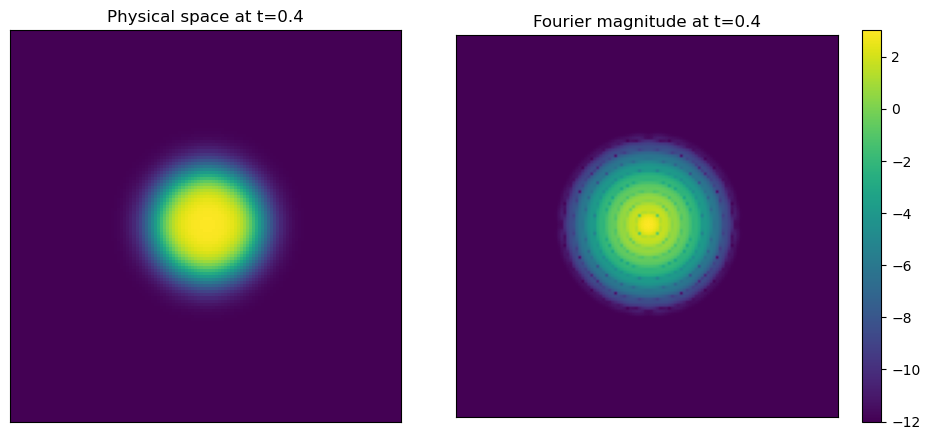

In [10]:
t = 0.4
u_t = heat_solution_fft_2d(u0, K2, kappa, t)
u_hat_t = np.exp(-kappa * K2 * t) * u0_hat
spectrum_t = np.log10(np.abs(np.fft.fftshift(u_hat_t)) + 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].imshow(u_t, origin='lower', extent=[0, Lx, 0, Ly], vmin=0.0, vmax=1.0)
axes[0].set_title(f'Physical space at t={t}')
axes[0].set_xticks([])
axes[0].set_yticks([])

im = axes[1].imshow(spectrum_t, origin='lower')
axes[1].set_title(f'Fourier magnitude at t={t}')
axes[1].set_xticks([])
axes[1].set_yticks([])
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()


## Step 10 — Why does diffusion smooth?

Every Fourier mode is multiplied by

$$e^{-\kappa (k^2+\ell^2)t}.$$

So modes with large $k^2+\ell^2$ decay quickly.

That means high-frequency spatial structure disappears first.

For a disk, the sharp boundary contains many high frequencies, so the boundary is what smooths out fastest.


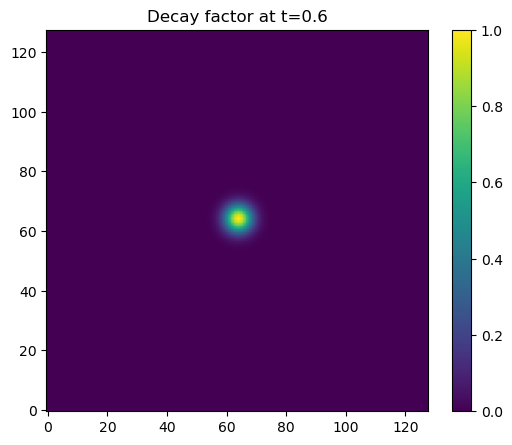

In [11]:
t = 0.6
decay = np.exp(-kappa * K2 * t)

plt.figure(figsize=(5.5, 4.5))
plt.imshow(np.fft.fftshift(decay), origin='lower')
plt.title(f'Decay factor at t={t}')
plt.colorbar()
plt.tight_layout()
plt.show()


## Step 11 — Animation

This cell creates an in-notebook animation of the heat diffusion process.

You can change the final time and the number of frames to make the animation smoother or faster.


In [12]:
t_final = 2.0
num_frames = 80
time_grid = np.linspace(0.0, t_final, num_frames)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(u0, origin='lower', extent=[0, Lx, 0, Ly], vmin=0.0, vmax=1.0)
title = ax.set_title('t = 0.0')
ax.set_xticks([])
ax.set_yticks([])

def update(frame):
    t = time_grid[frame]
    ut = heat_solution_fft_2d(u0, K2, kappa, t)
    im.set_data(ut)
    title.set_text(f't = {t:.3f}')
    return [im, title]

ani = FuncAnimation(fig, update, frames=num_frames, interval=70, blit=False)
plt.close(fig)
HTML(ani.to_jshtml())


## Step 12 — Optional single-mode check

If the initial condition is exactly one Fourier mode,

$$u(x,y,0)=\sin(mx)\cos(\ell y),$$

then the exact solution is

$$u(x,y,t)=e^{-\kappa(m^2+\ell^2)t}\sin(mx)\cos(\ell y).$$

This gives a clean correctness check.


In [13]:
m = 3
ell = 4
t = 0.9

u_mode = np.sin(m * X) * np.cos(ell * Y)
u_fft = heat_solution_fft_2d(u_mode, K2, kappa, t)
u_exact = np.exp(-kappa * (m**2 + ell**2) * t) * np.sin(m * X) * np.cos(ell * Y)

err = np.linalg.norm(u_fft - u_exact) / np.sqrt(nx * ny)
print('RMS error for single-mode test:', err)


RMS error for single-mode test: 9.732104040570401e-17


## Final summary

This notebook solved the 2D periodic heat equation by moving to Fourier space.

Key ideas:

- represent the solution in a Fourier basis
- the Laplacian becomes multiplication by $-(k^2+\ell^2)$
- evolve each mode exactly
- use the 2D FFT and inverse FFT to move between physical space and Fourier space efficiently
- view the same solution in both physical space and spectral space

With the hot-disk initial condition, you can see both:

- the **physical smoothing** of the circular boundary
- the **spectral damping** of high-frequency modes

## Suggested project extensions

- try a square, ring, or multiple disks as the initial condition
- compare a sharp disk to a smooth Gaussian blob
- track total energy decay over time
- compare against a finite-difference time-stepping solver
- build a side-by-side animation of physical space and Fourier magnitude
